---
title: "Crime Statistics Across States"
format: html
execute:
  echo: false
---

By Jordan Collins

In [69]:
import numpy as np
import pandas as pd

arrests_initial = pd.read_csv(r"C:\Users\jcoll\Desktop\Everything\2026 Berkeley Fall\STAT 215A\stat-215a\lab0\data\USArrests.csv")
statecoords = pd.read_csv(r"C:\Users\jcoll\Desktop\Everything\2026 Berkeley Fall\STAT 215A\stat-215a\lab0\data\stateCoord.csv")

In [70]:
#| include: false
arrests_initial

,State,Murder,Assault,UrbanPop,Rape
0,Alabama,13.2,236,58,21.2
1,Alaska,10.0,263,48,44.5
2,Arizona,8.1,294,80,31.0
3,Arkansas,8.8,190,50,19.5
4,California,9.0,276,91,40.6
5,Colorado,7.9,204,78,38.7
6,Connecticut,3.3,110,77,11.1
7,Delaware,5.9,238,72,15.8
8,Florida,15.4,335,80,31.9
9,Georgia,17.4,211,60,25.8


In [71]:
#| include: false
statecoords

,State,lon,lat
0,Alabama,-86.592392,34.735676
1,Alaska,-168.187471,53.330810
2,Arizona,-111.615136,36.246377
3,Arkansas,-92.240455,36.374502
4,California,-120.386476,34.034180
5,Colorado,-105.837605,40.112391
6,Connecticut,-72.750070,41.765316
7,Delaware,-75.573406,39.591903
8,Florida,-80.812851,24.823984
9,Georgia,-83.484813,34.804455


In [72]:
#| include: false
# Failed merge attempt, error indicates "State" is not a column
# reset_index() did not work
# Looking at the columns

print((list(arrests_initial.columns)))
print((list(statecoords.columns)))

['State', 'Murder', 'Assault', 'UrbanPop', 'Rape']
['State         ', 'lon              ', 'lat']


In [73]:
#| include: false
# State and lon have weird names in the statecoords dataframe
# Changing value of column name

statecoords = statecoords.rename(columns ={"State         " : "State"})
statecoords = statecoords.rename(columns ={"lon              " : "lon"})

# Check if change worked
print((list(arrests_initial.columns)))
print((list(statecoords.columns)))


['State', 'Murder', 'Assault', 'UrbanPop', 'Rape']
['State', 'lon', 'lat']


In [74]:
#| include: false
# Left merge gives all rows in left, but still no matches in the right
# Maybe a typing issue

print("arrests_initial state type: ", arrests_initial['State'].dtypes)
print('statecoords state type: ', statecoords['State'].dtypes)


arrests_initial state type:  str
statecoords state type:  str


In [75]:
#| include: false
# Same type, so that is not the issue;
# Look for white space with the repr() command
print(repr(arrests_initial['State'][0]))
print(repr(statecoords['State'][0])) # statecoords has extra white space!

'Alabama'
'Alabama       '


In [76]:
#| include: false
# Using the python strip() command to remove leading and trailing whitespace
statecoords['State'] = statecoords['State'].str.strip()

#check
arrests_initial['State'][0] == statecoords['State'][0]

True

In [77]:
#| include: false
# Hyphenated state names must be fixed
# Replacing all hyphens with a space in statecoords

statecoords['State'] = statecoords['State'].str.replace('-', ' ', regex = False)

In [78]:
#| include: false
# Try merge again

arrests = pd.merge(arrests_initial, statecoords, how="left", on="State")
arrests

,State,Murder,Assault,UrbanPop,Rape,lon,lat
0,Alabama,13.2,236,58,21.2,-86.592392,34.735676
1,Alaska,10.0,263,48,44.5,-168.187471,53.330810
2,Arizona,8.1,294,80,31.0,-111.615136,36.246377
3,Arkansas,8.8,190,50,19.5,-92.240455,36.374502
4,California,9.0,276,91,40.6,-120.386476,34.034180
5,Colorado,7.9,204,78,38.7,-105.837605,40.112391
6,Connecticut,3.3,110,77,11.1,-72.750070,41.765316
7,Delaware,5.9,238,72,15.8,-75.573406,39.591903
8,Florida,15.4,335,80,31.9,-80.812851,24.823984
9,Georgia,17.4,211,60,25.8,-83.484813,34.804455


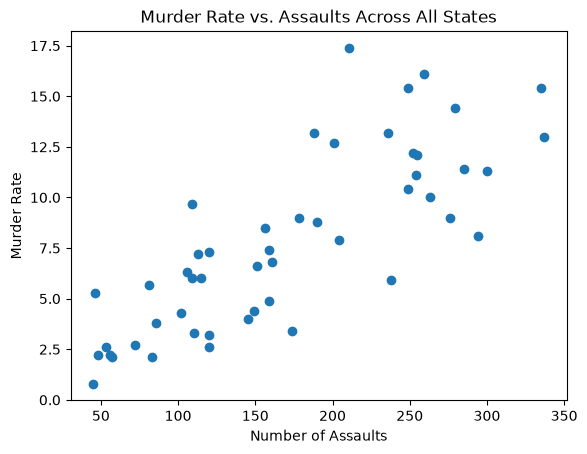

In [79]:
#  Plot "Murder" vs "Assault"

import matplotlib.pyplot as plt

plt.scatter(arrests['Assault'], arrests['Murder'])
plt.title("Murder Rate vs. Assaults Across All States")
plt.xlabel("Number of Assaults")
plt.ylabel("Murder Rate")
plt.show() 


When plotting Murder Rate vs. Number of Assaults Across All States, we see a general trend that indicates the higher number of assults that occur within a state, the higher the murder rate is likely to be.

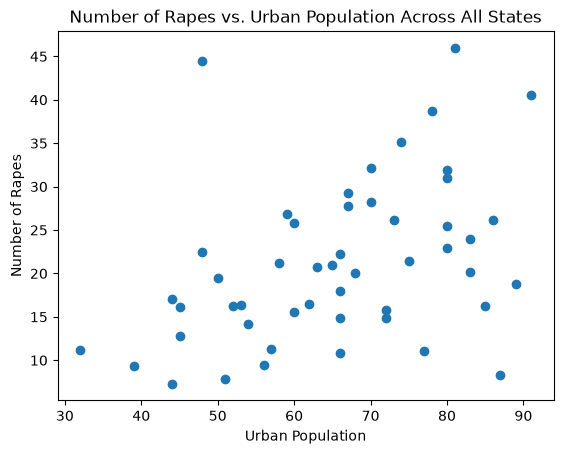

In [80]:
# Plot "Rape" vs "urban population"

plt.scatter(arrests['UrbanPop'], arrests['Rape'])
plt.title("Number of Rapes vs. Urban Population Across All States")
plt.xlabel("Urban Population")
plt.ylabel("Number of Rapes")
plt.show() 

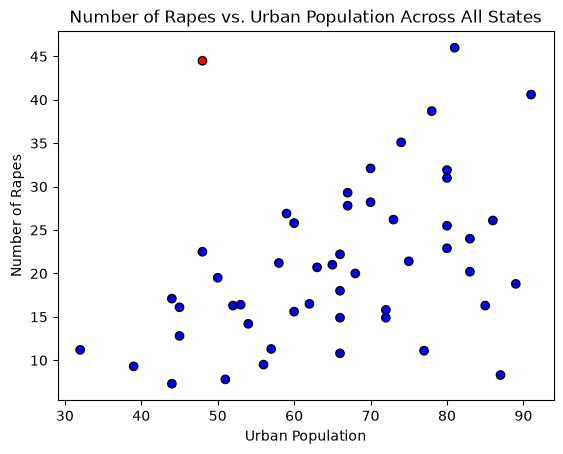

In [81]:
# Recreating the graph to highlight the outlier

colors = np.where(((arrests['UrbanPop'] < 60) & (arrests['Rape'] > 35)), 'red', 'blue')

plt.scatter(arrests['UrbanPop'], arrests['Rape'], c = colors, edgecolors="black")
plt.title("Number of Rapes vs. Urban Population Across All States")
plt.xlabel("Urban Population")
plt.ylabel("Number of Rapes")
plt.show() 

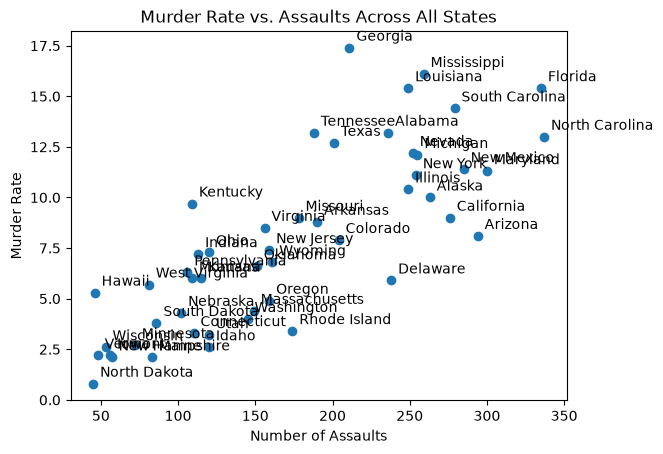

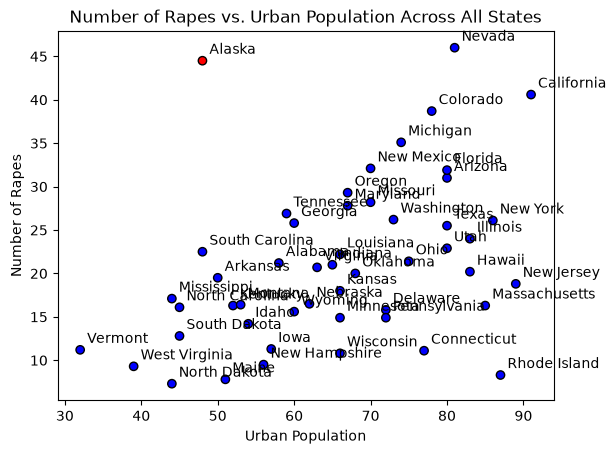

In [82]:
# Recreating graphs with state names

plt.scatter(arrests['Assault'], arrests['Murder'])
plt.title("Murder Rate vs. Assaults Across All States")
plt.xlabel("Number of Assaults")
plt.ylabel("Murder Rate")

# Include the annotations, plt.annotate needs a for loop to go through each row

for ind, row in arrests.iterrows():
    plt.annotate(text=row['State'], xy=(row['Assault'], row['Murder']),  xytext = (5,5), textcoords = 'offset points')

plt.show()

###########


colors = np.where(((arrests['UrbanPop'] < 60) & (arrests['Rape'] > 35)), 'red', 'blue')

plt.scatter(arrests['UrbanPop'], arrests['Rape'], c = colors, edgecolors="black")
plt.title("Number of Rapes vs. Urban Population Across All States")
plt.xlabel("Urban Population")
plt.ylabel("Number of Rapes")

for ind, row in arrests.iterrows():
    plt.annotate(text=row['State'], xy=(row['UrbanPop'], row['Rape']),  xytext = (5,5), textcoords = 'offset points')

plt.show()


Interestingly, there are many high murder rates and number of assults in the southern states of the US. 
There is also a general trend showing that as urban population increases, so do the number of rapes in that state. Alaska is the one state that is an outlier with a relatively smaller urban population, but a high number of rapes.

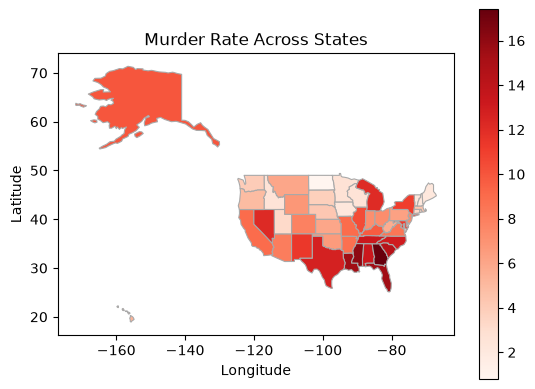

In [83]:
# Looking at Murder rate across states
# Needed to install !pip install geopandas

import geopandas as gpd

# Need USA boundaries

usa = "https://d2ad6b4ur7yvpq.cloudfront.net/naturalearth-3.3.0/ne_110m_admin_1_states_provinces.geojson"
states_boundaries = gpd.read_file(usa)

merged_map = pd.merge(states_boundaries, arrests, left_on="name", right_on= 'State', how='inner')

merged_map.plot(column='Murder', cmap='Reds', linewidth=0.8, edgecolor='darkgrey', legend=True)
plt.title("Murder Rate Across States")
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.show() 

In [84]:
#| include: false
# Drop Murder and Assault columns from arrests
#arrests = arrests.drop(columns = ['Murder', 'Assault'])
# Can only run the above code once

# Import sklearn

from sklearn.linear_model import LinearRegression

x = arrests[['Rape']]
y = arrests['UrbanPop']

model = LinearRegression()

model.fit(x,y)

print("Slope (Coefficient): ", round(model.coef_[0], 4))

Slope (Coefficient):  0.6357


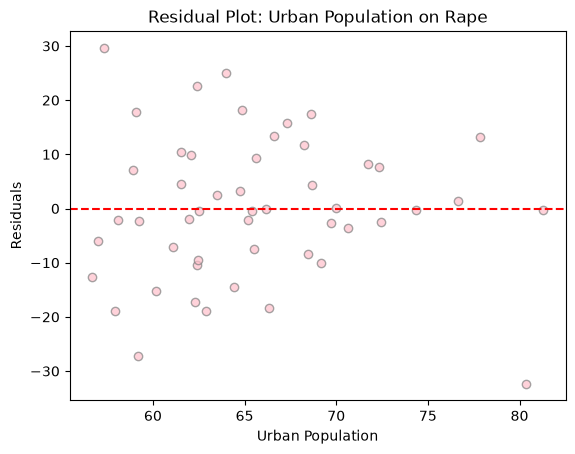

In [85]:
# Plotting residuals

y_predicted = model.predict(x) #predicting Urban Pop based on Rapes
residuals = y - y_predicted

plt.scatter(y_predicted, residuals, color = 'Pink', edgecolors = 'Grey', 
            alpha = 0.7)

plt.axhline(y=0, color = 'red', linestyle = '--')

plt.title('Residual Plot: Urban Population on Rape')
plt.xlabel("Urban Population")
plt.ylabel("Residuals")
plt.show() 

Funnel shape is seen in this graph, indicating heteroscedasticity. Low urban populations have a wider range of absolute residual values while higher urban populations have lower absolute resiudal values. There is one outlier in the bottom right.

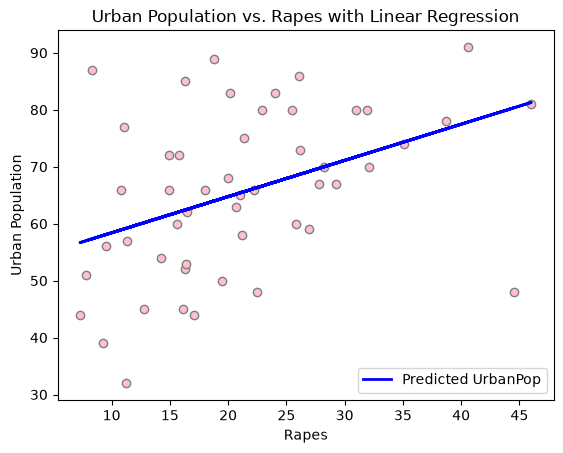

In [86]:
#| include: false
# Replot "Rape" vs "UrbanPop"; blue line with predicted responses

plt.scatter(arrests['Rape'], arrests['UrbanPop'], color = 'pink', edgecolor = 'grey')

plt.plot(arrests['Rape'], y_predicted, color='blue', linewidth=2, label = "Predicted UrbanPop")

plt.title('Urban Population vs. Rapes with Linear Regression')
plt.xlabel("Rapes")
plt.ylabel("Urban Population")
plt.legend()
plt.show() 

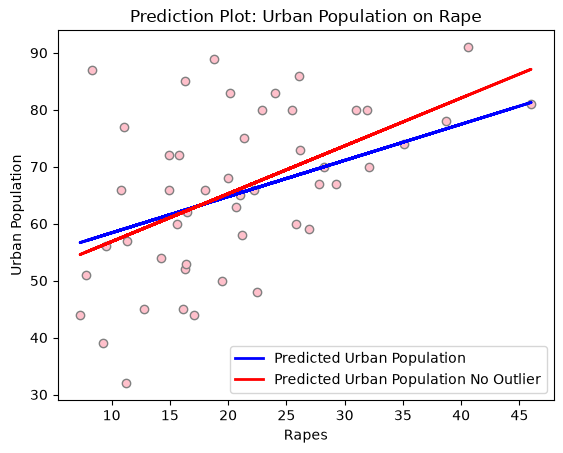

In [87]:
# Refitting without outlier

arrests['Residuals'] = arrests['UrbanPop'] - model.predict(arrests[['Rape']])
arrests_clean = arrests[arrests['Residuals'] > -30]

x_clean = arrests_clean[['Rape']]
y_clean = arrests_clean['UrbanPop']

model_clean = LinearRegression()

model_clean.fit(x_clean,y_clean)

y_predicted_clean = model_clean.predict(x_clean) #predicting Urban Pop based on Rapes
residuals_cl = y_clean - y_predicted_clean

plt.scatter(arrests_clean['Rape'], arrests_clean['UrbanPop'], color = 'pink', edgecolor = 'grey')


plt.plot(arrests['Rape'], y_predicted, color='blue', linewidth=2, label = "Predicted Urban Population")
plt.plot(arrests_clean['Rape'], y_predicted_clean, color='red', linewidth=2, label = "Predicted Urban Population No Outlier")


plt.title('Prediction Plot: Urban Population on Rape')
plt.xlabel("Rapes")
plt.ylabel("Urban Population")
plt.legend()
plt.show() 

Removing the outlier did change the results. The red line seems to show a more distinctive trend. However, there is still a large spread of urban populations, especially when there are fewer rape cases in a state. This makes the trendline seem less valuable and true to the data.
